# 05- Transformer Fine-Tuning (DistilBERT on OCR Text)

### 1: Mounting drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/capstone'
print(f"Working from: {BASE}")

Mounted at /content/drive
Working from: /content/drive/MyDrive/capstone


### 2: Seeds and config

In [ ]:
#Setting fixed seeds to ensure reprodcible results
import random
import numpy as np
import torch
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES   = 16
BATCH_SIZE    = 32
NUM_EPOCHS    = 3
LEARNING_RATE = 2e-5
MAX_LENGTH    = 256

LABEL_NAMES = ['letter', 'form', 'email', 'handwritten', 'advertisement',
               'scientific report', 'scientific publication', 'specification',
               'file folder', 'news article', 'budget', 'invoice',
               'presentation', 'questionnaire', 'resume', 'memo']

print(f"Seed: {SEED} | Device: {DEVICE}")
print(f"Batch: {BATCH_SIZE} | Epochs: {NUM_EPOCHS} | LR: {LEARNING_RATE}")

Seed: 42 | Device: cuda
Batch: 32 | Epochs: 3 | LR: 2e-05


### 3: Install required packages

In [ ]:
!pip install transformers torch scikit-learn pandas matplotlib seaborn tqdm --quiet
print("All packages are installed.")

All packages are installed.


### 4: Import libraries

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (DistilBertTokenizer,
                          DistilBertForSequenceClassification)
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json
import time
from tqdm import tqdm

print("All imports are fine.")
print(f"Device: {DEVICE}")

All imports are fine.
Device: cuda


### 5: Load saved text data from Drive

In [ ]:
#Loading OCR texts saved in notebook 03 — avoids rerunning Tesseract
print("Loading saved OCR texts from notebook 03")

with open(f"{BASE}/data/train_texts.json") as f:
    train_texts = json.load(f)

with open(f"{BASE}/data/val_texts.json") as f:
    val_texts = json.load(f)

print(f"Train texts: {len(train_texts)}")
print(f"Val texts  : {len(val_texts)}")
print(f"Sample text: {train_texts[0][:200]}")

Loading saved OCR texts from Milestone 2...
Train texts: 4000
Val texts  : 500
Sample text: es Oe
Joes
ative
i Creat! INVOICE NO. [ew
| Gomenurn Joa |
Communication, DATES
Inc. ACCOUNT NO. les |
1899 recep nererence| Bor eee |
P.O. how 1ee3e
St Lads, pe eas 1 x
INVOICE
WE. RA Veatch RELEASED


### 6: Reconstruct labels

In [ ]:
import json

#Loading actual lables saved from notebook 03
#Using real labels instead of reconstructed ones ensures correct training
print("Loading correct labels from Drive")

with open(f"{BASE}/data/train_labels.json") as f:
    train_labels = json.load(f)

with open(f"{BASE}/data/val_labels.json") as f:
    val_labels = json.load(f)

print(f"Train labels: {len(train_labels)}")
print(f"Val labels  : {len(val_labels)}")
print(f"Sample labels: {train_labels[:5]}")

from collections import Counter
dist = Counter(train_labels)
print("\nLabel distribution:")
for i in range(16):
    print(f"  {LABEL_NAMES[i]:25s}: {dist[i]}")

Loading correct labels from Drive...
Train labels: 4000
Val labels  : 500
Sample labels: [11, 5, 10, 9, 6]

Label distribution:
  letter                   : 235
  form                     : 239
  email                    : 289
  handwritten              : 269
  advertisement            : 276
  scientific report        : 226
  scientific publication   : 259
  specification            : 264
  file folder              : 249
  news article             : 245
  budget                   : 250
  invoice                  : 248
  presentation             : 221
  questionnaire            : 237
  resume                   : 237
  memo                     : 256


### 7: Load DistilBERT

In [ ]:
MODEL_NAME = "distilbert-base-uncased"

print(f"Loading: {MODEL_NAME}")

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

#num_labels=16 adds a new classification head for our 16 document classes
model     = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)
model = model.to(DEVICE)

print(f"Model loaded on {DEVICE}")
print(f"Total params    : {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading: distilbert-base-uncased


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on cuda
Total params    : 66,965,776
Trainable params: 66,965,776


In [ ]:
print(model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


### 8: Dataset class

In [ ]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = TextDataset(train_texts, train_labels, tokenizer)
val_dataset   = TextDataset(val_texts,   val_labels,   tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

Train batches: 125
Val batches  : 16


### 9: Training setup

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

#AdamW with weight_decay prevents overfitting
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

#CosineAnnealingLR gradually reduces LR for better convergence
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
criterion = nn.CrossEntropyLoss()

print(f"Optimizer : AdamW | LR: {LEARNING_RATE}")
print(f"Scheduler : CosineAnnealingLR")
print(f"Loss      : CrossEntropyLoss")

Optimizer : AdamW | LR: 2e-05
Scheduler : CosineAnnealingLR
Loss      : CrossEntropyLoss


### 10: Train and eval functions

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds  = []
    all_labels = []

    for batch in tqdm(loader, desc="Training"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)
        loss.backward()

        #Gradient clipping prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(outputs.logits.argmax(-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels)
            total_loss += loss.item()
            all_preds.extend(outputs.logits.argmax(-1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    #Macro F1 treats all classes equally regardless of sample size
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / len(loader), acc, f1, all_preds, all_labels

print("Functions is ready.")

Functions is ready.


### 11: Fine-tuning

In [ ]:
#Additional training epochs, model was still improving after initial 3 epochs
#Training stopped when val loss stopped improving and became stable around 1.31
NUM_EPOCHS_EXTRA = 9

for epoch in range(NUM_EPOCHS_EXTRA):
    print(f"\nExtra Epoch {epoch+1}/{NUM_EPOCHS_EXTRA}")
    print("-" * 40)
    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE)

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, criterion, DEVICE)

    scheduler.step()
    elapsed = time.time() - start

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  New best model saved (val_acc={val_acc:.4f})")

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val loss  : {val_loss:.4f}   | Val acc  : {val_acc:.4f} | F1: {val_f1:.4f}")
    print(f"  Time      : {elapsed/60:.1f} min")

print(f"\nBest val acc so far: {best_val_acc:.4f}")

In [ ]:
print("Starting fine-tuning")
print(f"Epochs: {NUM_EPOCHS} |")
print("=" * 55)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : [], 'val_f1': []
}

best_val_acc    = 0

#Save best model based on val accuracy, not with final epoch
best_model_path = f"{BASE}/outputs/results/best_distilbert_model.pt"

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)
    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE)

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, criterion, DEVICE)

    scheduler.step()
    elapsed = time.time() - start

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  New best model saved (val_acc={val_acc:.4f})")

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val loss  : {val_loss:.4f}   | Val acc  : {val_acc:.4f} | F1: {val_f1:.4f}")
    print(f"  Time      : {elapsed/60:.1f} min")

print(f"\nDone. Best val acc: {best_val_acc:.4f}")

Starting fine-tuning...
Epochs: 3 | ~5-8 min per epoch on T4 GPU

Epoch 1/3
----------------------------------------


Evaluating: 100%|██████████| 16/16 [00:03<00:00,  4.34it/s]


  New best model saved (val_acc=0.3160)
  Train loss: 2.4977 | Train acc: 0.2248
  Val loss  : 2.1775   | Val acc  : 0.3160 | F1: 0.2526
  Time      : 1.5 min

Epoch 2/3
----------------------------------------


Evaluating: 100%|██████████| 16/16 [00:03<00:00,  4.34it/s]


  New best model saved (val_acc=0.4240)
  Train loss: 1.9616 | Train acc: 0.4200
  Val loss  : 1.8541   | Val acc  : 0.4240 | F1: 0.3776
  Time      : 1.5 min

Epoch 3/3
----------------------------------------


Evaluating: 100%|██████████| 16/16 [00:03<00:00,  4.15it/s]


  New best model saved (val_acc=0.4700)
  Train loss: 1.7012 | Train acc: 0.5050
  Val loss  : 1.7097   | Val acc  : 0.4700 | F1: 0.4408
  Time      : 1.5 min

Done. Best val acc: 0.4700


In [ ]:
#Run 3 more epochs to improve the results
NUM_EPOCHS_EXTRA = 3

for epoch in range(NUM_EPOCHS_EXTRA):
    print(f"\nExtra Epoch {epoch+1}/{NUM_EPOCHS_EXTRA}")
    print("-" * 40)
    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE)

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, criterion, DEVICE)

    scheduler.step()
    elapsed = time.time() - start

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  New best model saved (val_acc={val_acc:.4f})")

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val loss  : {val_loss:.4f}   | Val acc  : {val_acc:.4f} | F1: {val_f1:.4f}")
    print(f"  Time      : {elapsed/60:.1f} min")

print(f"\nBest val acc so far: {best_val_acc:.4f}")


Extra Epoch 1/3
----------------------------------------


Evaluating: 100%|██████████| 16/16 [00:03<00:00,  4.11it/s]


  Train loss: 1.6157 | Train acc: 0.5312
  Val loss  : 1.7097   | Val acc  : 0.4700 | F1: 0.4408
  Time      : 1.5 min

Extra Epoch 2/3
----------------------------------------


Evaluating: 100%|██████████| 16/16 [00:03<00:00,  4.27it/s]


  New best model saved (val_acc=0.4960)
  Train loss: 1.5810 | Train acc: 0.5407
  Val loss  : 1.6366   | Val acc  : 0.4960 | F1: 0.4705
  Time      : 1.5 min

Extra Epoch 3/3
----------------------------------------


Evaluating: 100%|██████████| 16/16 [00:03<00:00,  4.16it/s]


  New best model saved (val_acc=0.5220)
  Train loss: 1.4573 | Train acc: 0.5815
  Val loss  : 1.4973   | Val acc  : 0.5220 | F1: 0.5086
  Time      : 1.5 min

Best val acc so far: 0.5220


In [ ]:
NUM_EPOCHS_EXTRA = 3

for epoch in range(NUM_EPOCHS_EXTRA):
    print(f"\nExtra Epoch {epoch+1}/{NUM_EPOCHS_EXTRA}")
    print("-" * 40)
    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE)

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, criterion, DEVICE)

    scheduler.step()
    elapsed = time.time() - start

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  New best model saved (val_acc={val_acc:.4f})")

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val loss  : {val_loss:.4f}   | Val acc  : {val_acc:.4f} | F1: {val_f1:.4f}")
    print(f"  Time      : {elapsed/60:.1f} min")

print(f"\nBest val acc so far: {best_val_acc:.4f}")


Extra Epoch 1/3
----------------------------------------


Evaluating: 100%|██████████| 16/16 [00:03<00:00,  4.20it/s]


  New best model saved (val_acc=0.5260)
  Train loss: 1.2517 | Train acc: 0.6395
  Val loss  : 1.4853   | Val acc  : 0.5260 | F1: 0.5115
  Time      : 1.5 min

Extra Epoch 2/3
----------------------------------------


Evaluating: 100%|██████████| 16/16 [00:03<00:00,  4.29it/s]


  New best model saved (val_acc=0.5640)
  Train loss: 1.0092 | Train acc: 0.7183
  Val loss  : 1.3527   | Val acc  : 0.5640 | F1: 0.5532
  Time      : 1.5 min

Extra Epoch 3/3
----------------------------------------


Evaluating: 100%|██████████| 16/16 [00:03<00:00,  4.23it/s]


  New best model saved (val_acc=0.5920)
  Train loss: 0.8319 | Train acc: 0.7808
  Val loss  : 1.3104   | Val acc  : 0.5920 | F1: 0.5853
  Time      : 1.5 min

Best val acc so far: 0.5920


In [ ]:
NUM_EPOCHS_EXTRA = 3

for epoch in range(NUM_EPOCHS_EXTRA):
    print(f"\nExtra Epoch {epoch+1}/{NUM_EPOCHS_EXTRA}")
    print("-" * 40)
    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE)

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, criterion, DEVICE)

    scheduler.step()
    elapsed = time.time() - start

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  New best model saved (val_acc={val_acc:.4f})")

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val loss  : {val_loss:.4f}   | Val acc  : {val_acc:.4f} | F1: {val_f1:.4f}")
    print(f"  Time      : {elapsed/60:.1f} min")

print(f"\nBest val acc so far: {best_val_acc:.4f}")


Extra Epoch 1/3
----------------------------------------


Evaluating: 100%|██████████| 16/16 [00:04<00:00,  3.97it/s]


  Train loss: 0.7629 | Train acc: 0.8100
  Val loss  : 1.3104   | Val acc  : 0.5920 | F1: 0.5853
  Time      : 1.5 min

Extra Epoch 2/3
----------------------------------------


Evaluating: 100%|██████████| 16/16 [00:03<00:00,  4.24it/s]


  New best model saved (val_acc=0.6000)
  Train loss: 0.7558 | Train acc: 0.8063
  Val loss  : 1.3192   | Val acc  : 0.6000 | F1: 0.5933
  Time      : 1.5 min

Extra Epoch 3/3
----------------------------------------


Evaluating: 100%|██████████| 16/16 [00:03<00:00,  4.15it/s]


  New best model saved (val_acc=0.6080)
  Train loss: 0.7320 | Train acc: 0.8015
  Val loss  : 1.3106   | Val acc  : 0.6080 | F1: 0.6026
  Time      : 1.5 min

Best val acc so far: 0.6080


### 12: Training curves

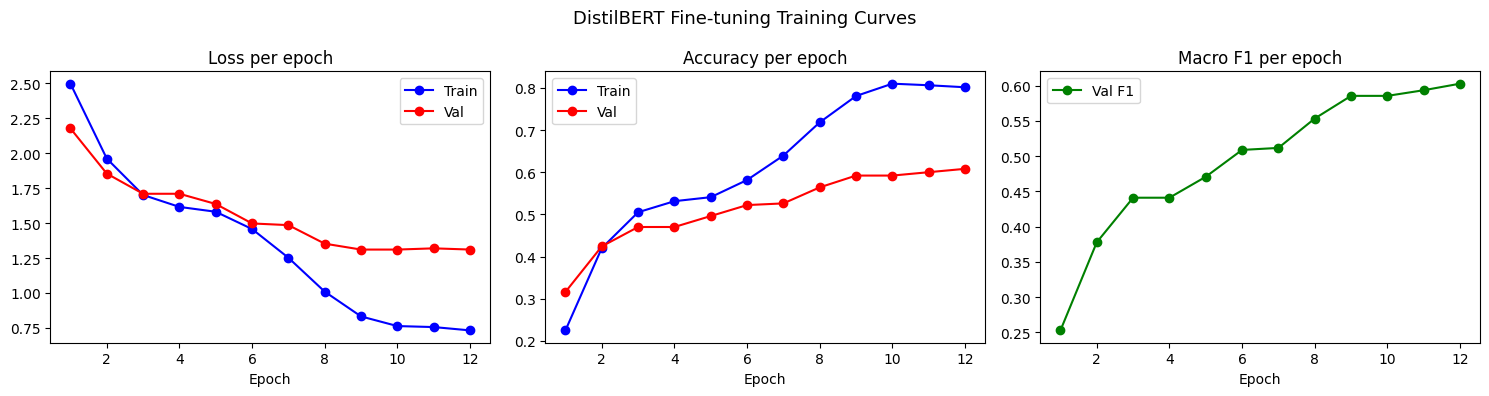

Training curves saved.


In [ ]:
#Using actual history length
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val')
axes[0].set_title("Loss per epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs, history['val_acc'],   'r-o', label='Val')
axes[1].set_title("Accuracy per epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(epochs, history['val_f1'], 'g-o', label='Val F1')
axes[2].set_title("Macro F1 per epoch")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.suptitle("DistilBERT Fine-tuning Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/distilbert_training_curves.png", dpi=150)
plt.show()
print("Training curves are saved.")

### 13: Load best model and evaluate

In [ ]:
#Load best checkpoint saved during training, not the final epoch
print("Loading best model")
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

val_loss, val_acc, val_f1, val_preds, val_labels = evaluate(
    model, val_loader, criterion, DEVICE)

print(f"\nFinal validation results:")
print(f"Accuracy : {val_acc:.4f}")
print(f"Macro F1 : {val_f1:.4f}")
print()
print(classification_report(val_labels, val_preds,
                             target_names=LABEL_NAMES, zero_division=0))

Loading best model...


Evaluating: 100%|██████████| 16/16 [00:03<00:00,  4.36it/s]


Final validation results:
Accuracy : 0.6080
Macro F1 : 0.6026

                        precision    recall  f1-score   support

                letter       0.43      0.43      0.43        21
                  form       0.58      0.59      0.58        32
                 email       0.80      0.82      0.81        34
           handwritten       0.72      0.42      0.53        31
         advertisement       0.41      0.50      0.45        34
     scientific report       0.62      0.60      0.61        35
scientific publication       0.86      0.60      0.71        40
         specification       0.54      0.72      0.62        18
           file folder       0.58      0.78      0.67        32
          news article       0.47      0.52      0.49        31
                budget       0.57      0.48      0.52        33
               invoice       0.58      0.52      0.55        29
          presentation       0.49      0.62      0.55        37
         questionnaire       0.83      

### 14: Confusion matrix

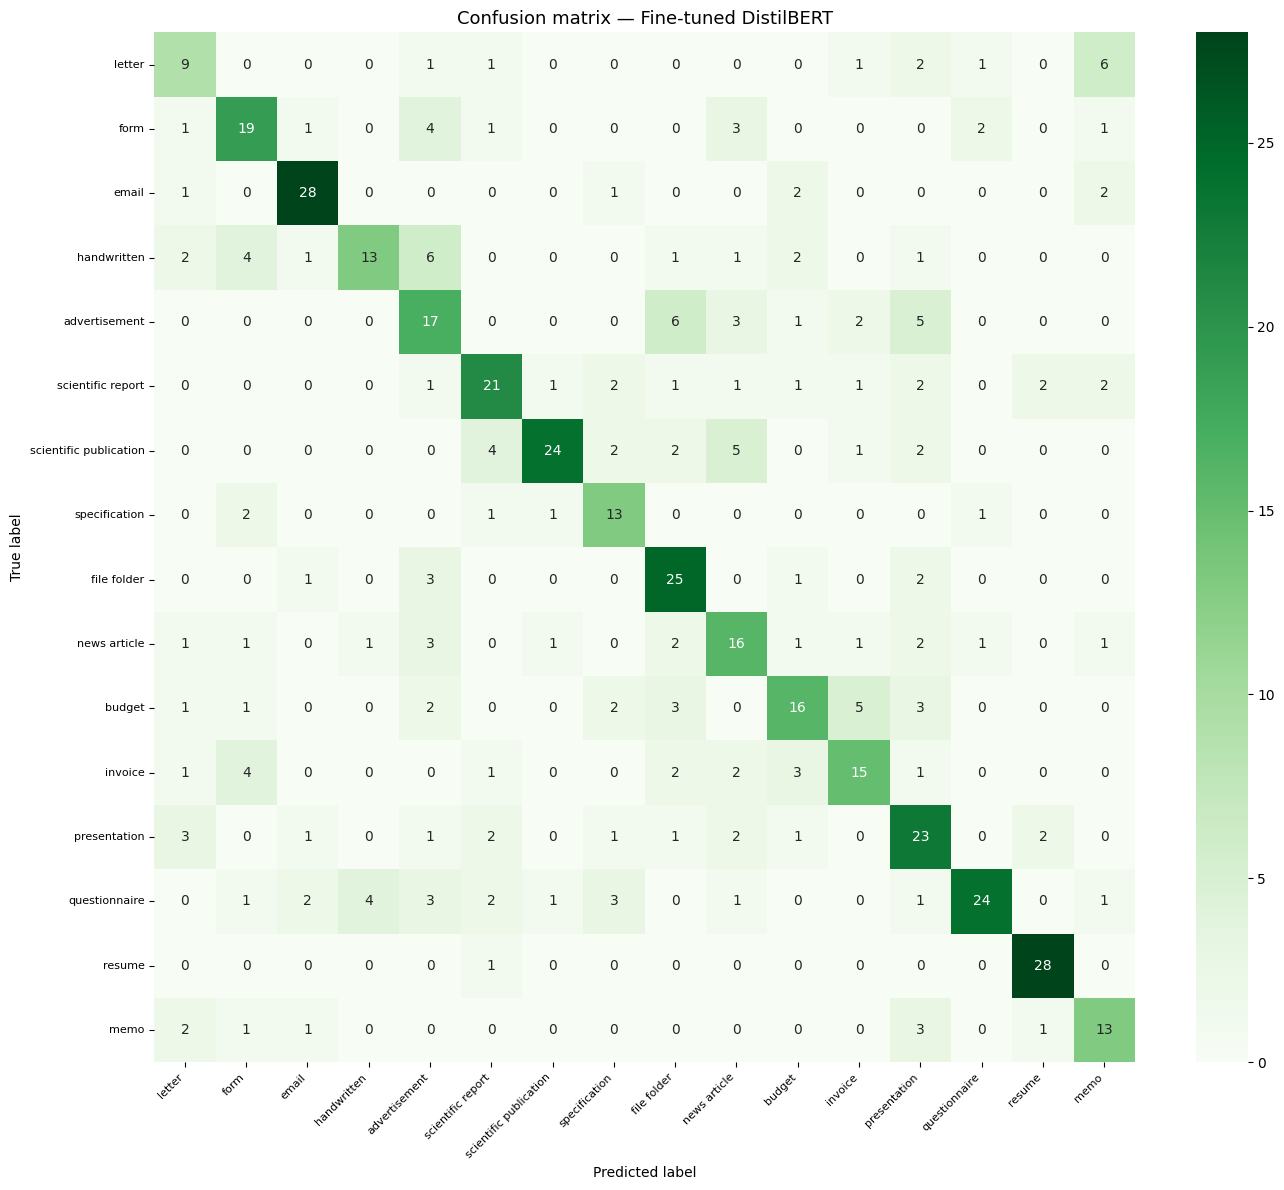

Confusion matrix saved.


In [ ]:
cm = confusion_matrix(val_labels, val_preds)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES,
            cmap='Greens', ax=ax)
ax.set_title("Confusion matrix — Fine-tuned DistilBERT", fontsize=13)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/finetuned_distilbert_confusion_matrix.png",
            dpi=150)
plt.show()
print("Confusion matrix saved.")

### 15: Full comparison table

In [ ]:
with open(f"{BASE}/outputs/results/baseline_results.json") as f:
    baseline = json.load(f)

with open(f"{BASE}/outputs/results/vlm_results.json") as f:
    zeroshot = json.load(f)

comparison = pd.DataFrame({
    "Method"       : ["OCR + TF-IDF + SVM (baseline)",
                      "ViT zero-shot (M2)",
                      "DistilBERT fine-tuned (M3)"],
    "Accuracy"     : [baseline['accuracy'],
                      zeroshot['accuracy'],
                      round(val_acc, 4)],
    "Macro F1"     : [baseline['macro_f1'],
                      zeroshot['macro_f1'],
                      round(val_f1, 4)],
    "Approach"     : ["OCR + classical ML",
                      "Vision model zero-shot",
                      "Transformer fine-tuned on OCR text"],
    "Fine-tuned"   : ["No", "No", "Yes"]
})

print("=" * 75)
print("FULL COMPARISON")
print("=" * 75)
print(comparison.to_string(index=False))
print("=" * 75)

comparison.to_csv(f"{BASE}/outputs/results/final_comparison.csv", index=False)
print("File is saved.")

FULL COMPARISON — MILESTONE 3
                       Method  Accuracy  Macro F1                           Approach Fine-tuned
OCR + TF-IDF + SVM (baseline)     0.566    0.5643                 OCR + classical ML         No
           ViT zero-shot (M2)     0.070    0.0436             Vision model zero-shot         No
   DistilBERT fine-tuned (M3)     0.608    0.6026 Transformer fine-tuned on OCR text        Yes
Saved.


### 16: Save results

In [ ]:
#Saving all hyperparameters and results, which are loaded by notebook 07
finetuned_results = {
    "model"         : "distilbert-base-uncased",
    "approach"      : "fine-tuned on OCR-extracted text from RVL-CDIP",
    "train_samples" : len(train_texts),
    "val_samples"   : len(val_texts),
    "epochs"        : NUM_EPOCHS,
    "batch_size"    : BATCH_SIZE,
    "learning_rate" : LEARNING_RATE,
    "max_length"    : MAX_LENGTH,
    "accuracy"      : round(val_acc, 4),
    "macro_f1"      : round(val_f1, 4),
    "best_val_acc"  : round(best_val_acc, 4),
    "random_seed"   : SEED,
    "device"        : DEVICE,
    "optimizer"     : "AdamW",
    "scheduler"     : "CosineAnnealingLR"
}

with open(f"{BASE}/outputs/results/finetuned_results.json", "w") as f:
    json.dump(finetuned_results, f, indent=2)

print("Results is saved:")
print(json.dumps(finetuned_results, indent=2))

Results saved:
{
  "model": "distilbert-base-uncased",
  "approach": "fine-tuned on OCR-extracted text from RVL-CDIP",
  "train_samples": 4000,
  "val_samples": 500,
  "epochs": 3,
  "batch_size": 32,
  "learning_rate": 2e-05,
  "max_length": 256,
  "accuracy": 0.608,
  "macro_f1": 0.6026,
  "best_val_acc": 0.608,
  "random_seed": 42,
  "device": "cuda",
  "optimizer": "AdamW",
  "scheduler": "CosineAnnealingLR"
}


### 17: Error analysis

In [ ]:
from collections import Counter

errors = [(i, val_labels[i], val_preds[i])
          for i in range(len(val_labels))
          if val_labels[i] != val_preds[i]]

print(f"Misclassified : {len(errors)} / {len(val_labels)}")
print(f"Accuracy      : {1 - len(errors)/len(val_labels):.4f}")
print()

pairs = Counter([(LABEL_NAMES[t], LABEL_NAMES[p]) for _, t, p in errors])
print("Top 10 misclassification pairs (true → predicted):")
for (true, pred), count in pairs.most_common(10):
    print(f"  {true:30s} → {pred:30s} : {count}")

with open(f"{BASE}/outputs/results/finetuned_error_analysis.json", "w") as f:
    json.dump({
        "total_errors"  : len(errors),
        "total_samples" : len(val_labels),
        "top_confusions": [{"true": t, "predicted": p, "count": c}
                           for (t, p), c in pairs.most_common(10)]
    }, f, indent=2)
print("Error analysis is saved.")

Misclassified : 196 / 500
Accuracy      : 0.6080

Top 10 misclassification pairs (true → predicted):
  letter                         → memo                           : 6
  handwritten                    → advertisement                  : 6
  advertisement                  → file folder                    : 6
  budget                         → invoice                        : 5
  advertisement                  → presentation                   : 5
  scientific publication         → news article                   : 5
  scientific publication         → scientific report              : 4
  form                           → advertisement                  : 4
  questionnaire                  → handwritten                    : 4
  handwritten                    → form                           : 4
Error analysis saved.
